In [13]:
import pandas as pd

df = pd.read_csv("mg3dn6kmtx9y0bnr.csv")
df['strike_price'] /= 1000
df.head()

,date,symbol,exdate,cp_flag,strike_price,best_bid,best_offer,impl_volatility,delta,gamma,vega,theta,optionid,expiry_indicator,index_flag,exchange_d,issuer,exercise_style
0,2024-08-29,SPXW 240829C2200000,2024-08-29,C,2200.0,3390.8,3397.8,NaN,NaN,NaN,NaN,NaN,163336418,NaN,1,32768,CBOE S&P 500 INDEX,E
1,2024-08-29,SPXW 240829C2400000,2024-08-29,C,2400.0,3190.8,3197.8,NaN,NaN,NaN,NaN,NaN,163244342,NaN,1,32768,CBOE S&P 500 INDEX,E
2,2024-08-29,SPXW 240829C2600000,2024-08-29,C,2600.0,2990.7,2997.8,NaN,NaN,NaN,NaN,NaN,163244343,NaN,1,32768,CBOE S&P 500 INDEX,E
3,2024-08-29,SPXW 240829C2800000,2024-08-29,C,2800.0,2790.8,2797.8,NaN,NaN,NaN,NaN,NaN,163244344,NaN,1,32768,CBOE S&P 500 INDEX,E
4,2024-08-29,SPXW 240829C3000000,2024-08-29,C,3000.0,2590.8,2597.8,NaN,NaN,NaN,NaN,NaN,163244345,NaN,1,32768,CBOE S&P 500 INDEX,E


In [14]:
df = df[(df['date']=='2024-08-29') & (df['cp_flag']=='C')]
df['mid_price'] = (df['best_bid'] + df['best_offer']) / 2

In [59]:
import numpy as np

S = 5500.26  # SPY price

df['moneyness'] = np.log(S/df['strike_price'] )

In [60]:
df['moneyness']

0      0.916338
1      0.829327
2      0.749284
3      0.675176
4      0.606183
         ...   
203   -0.151503
204   -0.182274
205   -0.212127
206   -0.241115
207   -0.269286
Name: moneyness, Length: 208, dtype: float64

In [61]:
from scipy.stats import norm
import numpy as np

def bs_call_price(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

In [66]:
from scipy.optimize import brentq

def implied_vol_call(price, S, K, T, r):
    
    f = lambda sigma: bs_call_price(S, K, T, r, sigma) - price
    
    try:
        return brentq(f, -1e-4, 10)
    except:
        return np.nan

In [67]:
T = 1/365    # 0DTE approx
r = 0.05       # risk-free rate

df['iv'] = df.apply(
    lambda row: implied_vol_call(
        row['mid_price'],
        S,
        row['strike_price'],
        T,
        r
    ),
    axis=1
)

In [68]:
df[['moneyness', 'iv']]

,moneyness,iv
0,0.916338,NaN
1,0.829327,NaN
2,0.749284,NaN
3,0.675176,NaN
4,0.606183,9.158380
...,...,...
203,-0.151503,0.855876
204,-0.182274,1.015479
205,-0.212127,1.168457
206,-0.241115,1.315501


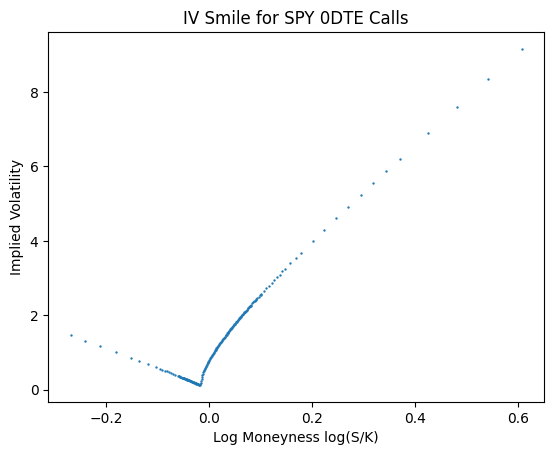

In [69]:
import matplotlib.pyplot as plt

plt.scatter(df['moneyness'], df['iv'], s=.5)
plt.xlabel("Log Moneyness log(S/K)")
plt.ylabel("Implied Volatility")
plt.title("IV Smile for SPY 0DTE Calls")
plt.show()

In [58]:
import yfinance as yf
import pandas as pd

# ticker for S&P 500 index
ticker = "SPY"

# download 1-minute intraday data
data = yf.download(
    ticker,
    start="2024-08-29",
    end="2024-09-30",   # end must be next day
    interval="1d",
    auto_adjust=True,
    progress=False
)

# keep regular market hours
# data = data.between_time("09:30", "16:00")

print(data.head())
print(data.tail())

# save if you want
data.to_csv("spx_intraday_2024_08_29.csv")

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2024-08-29  548.336182  553.570607  547.187182  550.261051  38715200
2024-08-30  553.570618  554.081311  547.147932  550.712834  62700100
2024-09-03  542.178589  550.751999  539.654674  550.418071  60600100
2024-09-04  541.068970  544.486538  539.605702  540.332421  47224900
2024-09-05  539.752930  543.867786  537.287936  541.010002  44264300
Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2024-09-23  561.169189  561.819374  559.622610  560.844157  44116900
2024-09-24  562.774902  562.834005  559.130103  561.967131  46805700
2024-09-25  561.533630  563.356060  560.420488  562.617252  38428600
2024-09-26  563.759949  566.134020